# Poisson Solver Testing - Slightly Nonuniform Grids

## Grids Tested

**Angular grids** (fixed across all radii):

- **Uniform:** $\theta_j = 2\pi j / N$
- **Stratified-random:** one random angle drawn inside each uniform sector $[2\pi j/N,\, 2\pi(j+1)/N)$ — nonuniform but gap-free
- **Jittered:** cell-center angles perturbed by up to 35% of a cell width, $\theta_j = \frac{2\pi}{N}(j+\tfrac12) + \delta_j$

## Method Suite

Three solvers:

- **FFT** (uniform grid only): standard equispaced FFT, exact and fastest.
- **NUDFT**: direct nonuniform DFT solved via regularized least-squares 
- **NUFFT**: fast nonuniform transform via FINUFFT, solved with the Toeplitz/Block-CG pathway — a fast Toeplitz operator built from FFT-KDE density weights with a T. Chan circulant preconditioner, solved via Block CG.

We use the Toeplitz/Block-CG solver rather than the alternative unsquared PCGLS path because condition numbers arent to bad, so the method is both faster and will converge

In [1]:
import os, sys
import pandas as pd
# Main project root
repo_root = r"c:\Users\charl\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from Tests.CPU.testing_helpers import (
    run_tests_pipeline,
    set_global_config,
    get_global_config,
    render_accuracy,
    render_runtime,
    render_table2_accuracy,
    render_table2_runtime,
    plot_accuracy_table1,
    plot_runtime_table1,
    plot_accuracy_table2,
    plot_runtime_table2,
    plot_accuracy_comparison,
    plot_runtime_comparison
)


c:\Users\charl\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Setup & Configurable Parameters

In [2]:
# =============================================================================
# Domain & Solver Parameters
# =============================================================================
R = 1.0                     # Disk radius
RAD_UNIF = 1                # 1: Uniform radial grid
RADIAL_MAPPING = None       # Non-uniform radial mapping if RAD_UNIF == 0
QUAD_RULE = 1               # 1: Trapezoidal, 2: Simpson's rule
BC_CHOICE = 1               # 1: Dirichlet, 2: Neumann


# Solver Tolerances & Regularization (Lambda)
TOL_NUFFT = 1e-10           # CG residual tolerance for NUFFT
MAXITER_NUFFT = 100         # Maximum CG iterations (50-100 is optimal)
EPS_FINUFFT = 1e-12         # FINUFFT kernel precision (optimal W=10 width)
REG_PARAM = 1e-20           # Regularization parameter



PRECOND_SHIFT = 1e-3        # Circulant preconditioner regularization shift (Toeplitz/Block-CG)
KDE_OVERSAMPLE = 4          # FFT-KDE oversampling factor for density weights
KDE_BANDWIDTH = 1.0         # FFT-KDE bandwidth for density weights



# =============================================================================
# Problem Selection
# =============================================================================
PROBLEM_TYPE = 0            # 0: Borges & Daripa Problem 1, 2: Problem 2
CUSTOM_PROBLEM = None
# Apply global configuration
set_global_config(
    R=R,
    rad_unif=RAD_UNIF,
    radial_mapping=RADIAL_MAPPING,
    tol_nufft=TOL_NUFFT,
    maxiter_nufft=MAXITER_NUFFT,
    eps_finufft=EPS_FINUFFT,
    reg_param=REG_PARAM,
    quad_rule=QUAD_RULE,
    BC_choice=BC_CHOICE,
    precond_shift=PRECOND_SHIFT,
    kde_oversample=KDE_OVERSAMPLE,
    kde_bandwidth=KDE_BANDWIDTH,
    problem_type=PROBLEM_TYPE,
    custom_problem=CUSTOM_PROBLEM,
)


# =============================================================================
# Grid Sweep Resolutions
# =============================================================================


N_vals_p1 = [32, 64, 128, 256, 512]
M_vals_p1 = [32, 64, 128, 256, 512]
N_fixed_p1 = 128


N_vals_c = [32, 64, 128, 256, 512]
M_vals_c = [32, 64, 128, 256, 512]
N_fixed_c = 128
M_fixed_c = 128


MUTE_OUTPUT = True

# Run Problems

In [3]:
METHODS_p1 = [
    dict(name="Unif-FFT", label="Uniform / FFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=2, use_nudft=None),
    dict(name="Fixed-stratified_rand-NUDFT", label="Fixed stratified / NUDFT", azu_unif=1, mesh_kind="stratified_rand", solver_azu_unif=1, use_nudft=True),
    dict(name="Fixed-stratified_rand-NUFFT", label="Fixed stratified / NUFFT", azu_unif=1, mesh_kind="stratified_rand", solver_azu_unif=1, use_nudft=False),
]

METHODS_COMP = [
    dict(name="Unif-FFT", label="Uniform / FFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=2, use_nudft=None),
    dict(name="Unif-NUDFT", label="Uniform / NUDFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=1, use_nudft=True),
    dict(name="Unif-NUFFT", label="Uniform / NUFFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=1, use_nudft=False),
]

for kind in ("stratified_rand", "jittered"):
    METHODS_COMP += [
        dict(name=f"Fixed-{kind}-NUDFT", label=f"Fixed {kind} / NUDFT", azu_unif=1, mesh_kind=kind, solver_azu_unif=1, use_nudft=True),
        dict(name=f"Fixed-{kind}-NUFFT", label=f"Fixed {kind} / NUFFT", azu_unif=1, mesh_kind=kind, solver_azu_unif=1, use_nudft=False),
    ]

print("\nRunning Problem 1, Table 1: N–M resolution sweep "
      "(fixed stratified-random angular grid)...")

df_p1_t1 = run_tests_pipeline(
    N_vals_p1, M_vals_p1,
    fixed_other=None,
    methods=METHODS_p1,
    test_type="P1_Table1",
    mute=MUTE_OUTPUT,
)

print(f"\nRunning Problem 1, Table 2: boundary-condition and quadrature sweep "
      f"(fixed N={N_fixed_p1}; stratified-random angular grid)...")

df_p1_t2 = run_tests_pipeline(
    None, M_vals_p1,
    fixed_other=N_fixed_p1,
    methods=METHODS_p1,
    test_type="P1_Table2",
    mute=MUTE_OUTPUT,
)

print("\nRunning slight-nonuniform angular-grid accuracy comparisons...")

print(f"Varying angular resolution N with fixed radial resolution M={M_fixed_c}")
df_cN = run_tests_pipeline(
    N_vals_c, None,
    fixed_other=M_fixed_c,
    methods=METHODS_COMP,
    test_type="Accuracy_VaryN",
    mute=MUTE_OUTPUT,
)


print(f"  • Varying radial resolution M with fixed angular resolution N={N_fixed_c}")
df_cM = run_tests_pipeline(
    None, M_vals_c,
    fixed_other=N_fixed_c,
    methods=METHODS_COMP,
    test_type="Accuracy_VaryM",
    mute=MUTE_OUTPUT,
)

print("Benchmark runs complete.")


Running Problem 1, Table 1: N–M resolution sweep (fixed stratified-random angular grid)...


Pipeline (P1_Table1): 100%|██████████| 3/3 [00:22<00:00,  7.51s/it, method=Fixed-stratified_rand-NUFFT]



Running Problem 1, Table 2: boundary-condition and quadrature sweep (fixed N=128; stratified-random angular grid)...


Pipeline (P1_Table2): 100%|██████████| 3/3 [00:08<00:00,  2.96s/it, method=Fixed-stratified_rand-NUFFT]



Running slight-nonuniform angular-grid accuracy comparisons...
Varying angular resolution N with fixed radial resolution M=128


Pipeline (Accuracy_VaryN): 100%|██████████| 7/7 [00:06<00:00,  1.09it/s, method=Fixed-jittered-NUFFT]       


  • Varying radial resolution M with fixed angular resolution N=128


Pipeline (Accuracy_VaryM): 100%|██████████| 7/7 [00:04<00:00,  1.46it/s, method=Fixed-jittered-NUFFT]       

Benchmark runs complete.


# Accuracy across different Meshes


Slightly Nonuniform Angular-Grid Comparison: Relative L2 Error vs. N
Varying angular resolution N; fixed radial resolution M=128
Meshes: uniform, stratified-random, and jittered

Accuracy Comparison (Fixed M=128) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed jittered / NUDFT,Fixed stratified_rand / NUDFT,Fixed jittered / NUFFT,Fixed stratified_rand / NUFFT
N,,,,,,,
32,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.56e-07,6.55e-07,6.56e-07
64,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07
128,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07
256,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07
512,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07


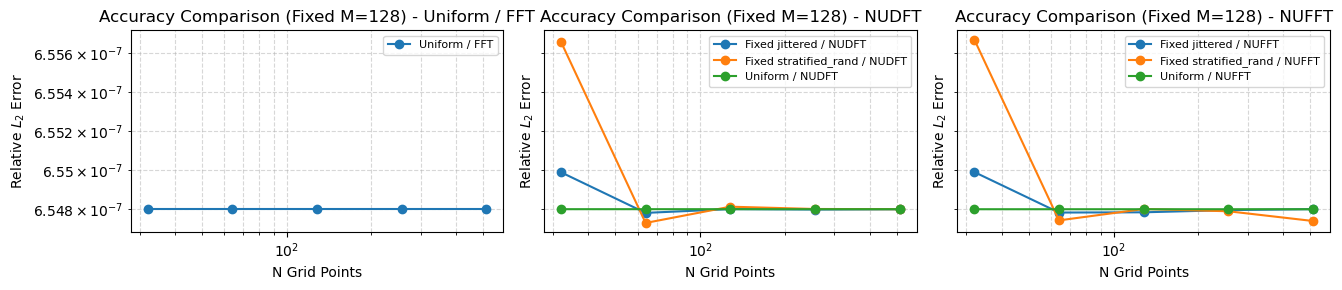


Slightly Nonuniform Angular-Grid Comparison: Relative L2 Error vs. M
Varying radial resolution M; fixed angular resolution N=128
Meshes: uniform, stratified-random, and jittered

Accuracy Comparison (Fixed N=128) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed jittered / NUDFT,Fixed stratified_rand / NUDFT,Fixed jittered / NUFFT,Fixed stratified_rand / NUFFT
M,,,,,,,
32,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05
64,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06
128,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07
256,1.62e-07,1.62e-07,1.62e-07,1.62e-07,1.62e-07,1.62e-07,1.62e-07
512,4.04e-08,4.04e-08,4.04e-08,4.04e-08,4.04e-08,4.04e-08,4.04e-08


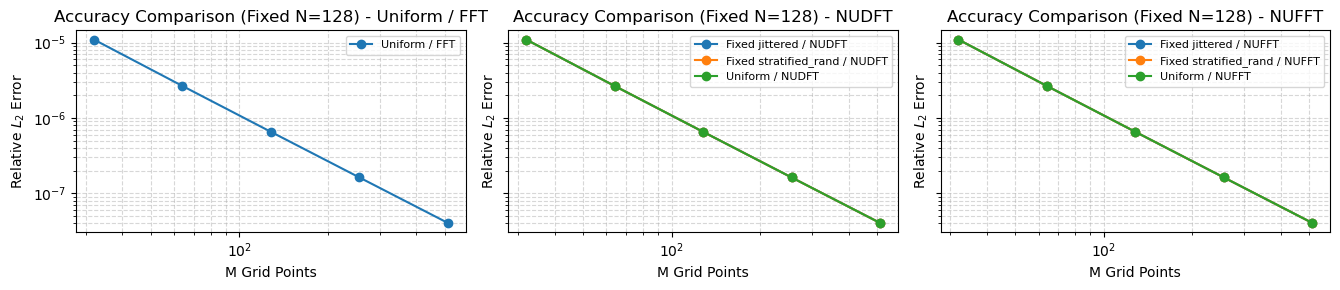

In [4]:
print("\nSlightly Nonuniform Angular-Grid Comparison: Relative L2 Error vs. N")
print(f"Varying angular resolution N; fixed radial resolution M={M_fixed_c}")
print("Meshes: uniform, stratified-random, and jittered")
render_accuracy(
    df_cN,
    index_col="N",
    columns_col="label",
    title_prefix=f"Accuracy Comparison (Fixed M={M_fixed_c})"
)
plot_accuracy_comparison(
    df_cN,
    index_col="N",
    title_prefix=f"Accuracy Comparison (Fixed M={M_fixed_c})"
)

print("\nSlightly Nonuniform Angular-Grid Comparison: Relative L2 Error vs. M")
print(f"Varying radial resolution M; fixed angular resolution N={N_fixed_c}")
print("Meshes: uniform, stratified-random, and jittered")
render_accuracy(
    df_cM,
    index_col="M",
    columns_col="label",
    title_prefix=f"Accuracy Comparison (Fixed N={N_fixed_c})"
)
plot_accuracy_comparison(
    df_cM,
    index_col="M",
    title_prefix=f"Accuracy Comparison (Fixed N={N_fixed_c})"
)


# Accuracy for stratified random grid


Problem 1 — Table 1: Relative L2 error over angular and radial resolutions
Methods: uniform FFT and fixed stratified-random NUDFT/NUFFT

Problem 1 — Table 1 Accuracy


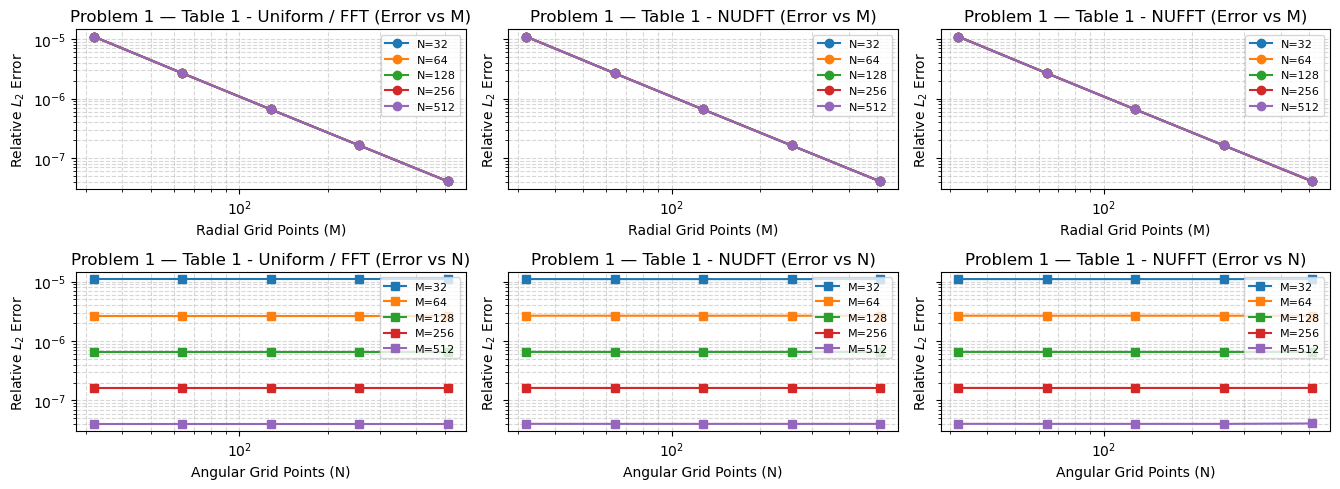


Problem 1 — Table 2: Relative L2 error by quadrature rule and boundary condition (N=128)
Methods: uniform FFT and fixed stratified-random NUDFT/NUFFT

Problem 1 — Table 2 (Fixed N=128) Accuracy


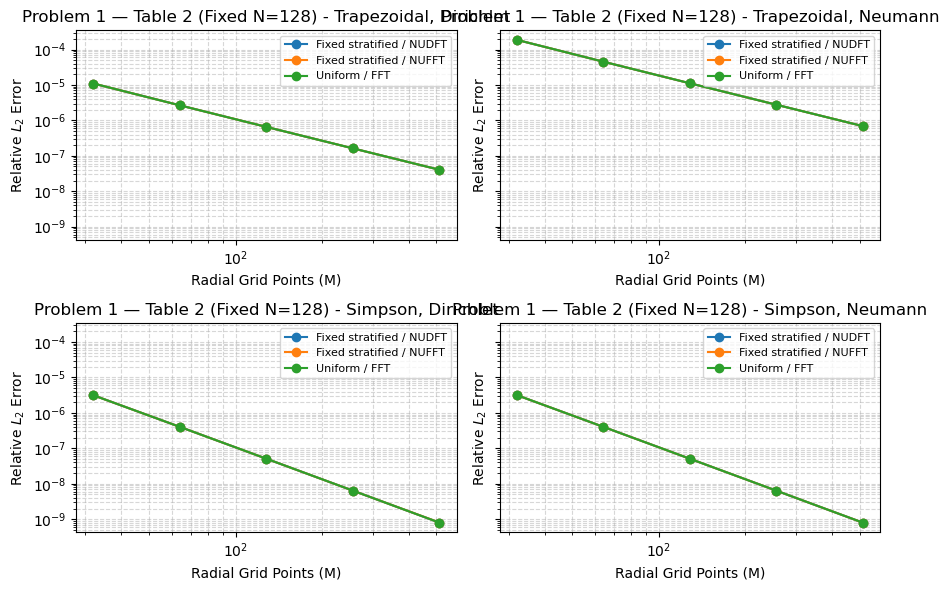

In [5]:
print("\nProblem 1 — Table 1: Relative L2 error over angular and radial resolutions")
print("Methods: uniform FFT and fixed stratified-random NUDFT/NUFFT")
render_accuracy(
    df_p1_t1,
    index_col="N",
    columns_col=["label", "M"],
    title_prefix="Problem 1 — Table 1"
)
plot_accuracy_table1(df_p1_t1, title_prefix="Problem 1 — Table 1")

print(f"\nProblem 1 — Table 2: Relative L2 error by quadrature rule and boundary condition (N={N_fixed_p1})")
print("Methods: uniform FFT and fixed stratified-random NUDFT/NUFFT")
render_table2_accuracy(
    df_p1_t2,
    title_prefix=f"Problem 1 — Table 2 (Fixed N={N_fixed_p1})"
)
plot_accuracy_table2(
    df_p1_t2,
    title_prefix=f"Problem 1 — Table 2 (Fixed N={N_fixed_p1})"
)

# Runtimes


Problem 1 — Table 1: Runtime over angular and radial resolutions
Methods: uniform FFT and fixed stratified-random NUDFT/NUFFT

Problem 1 — Table 1 Runtime (s)


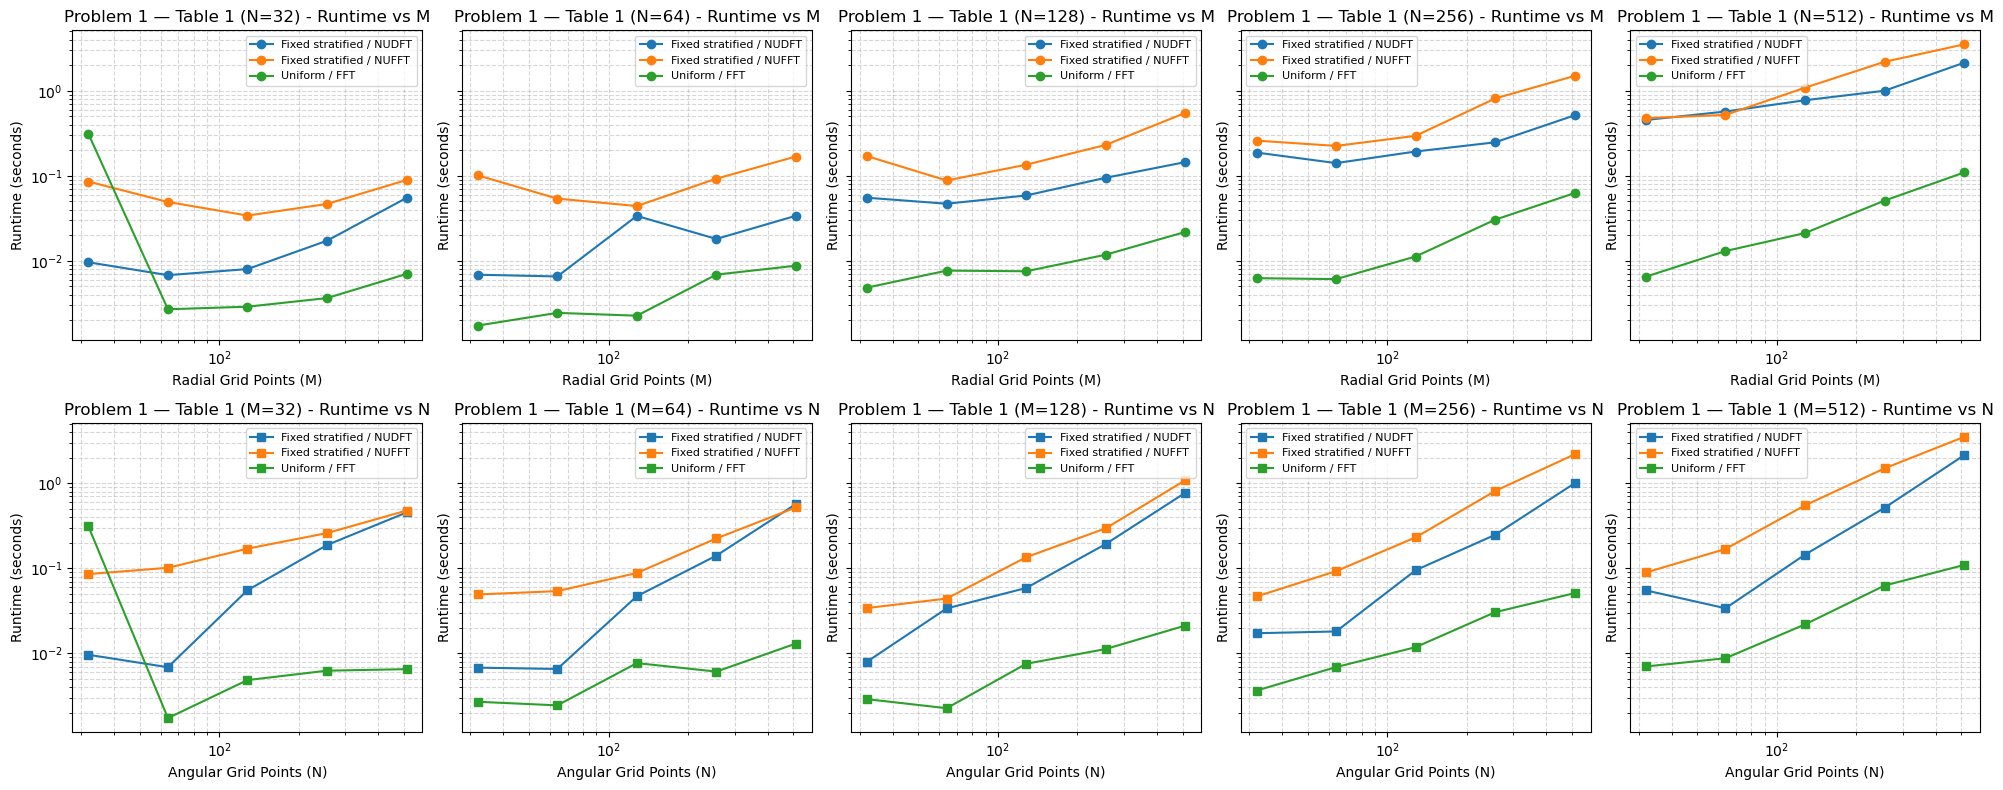


Problem 1 — Table 2: Runtime by quadrature rule and boundary condition (N=128)
Methods: uniform FFT and fixed stratified-random NUDFT/NUFFT

Problem 1 — Table 2 (Fixed N=128) Runtime (s)


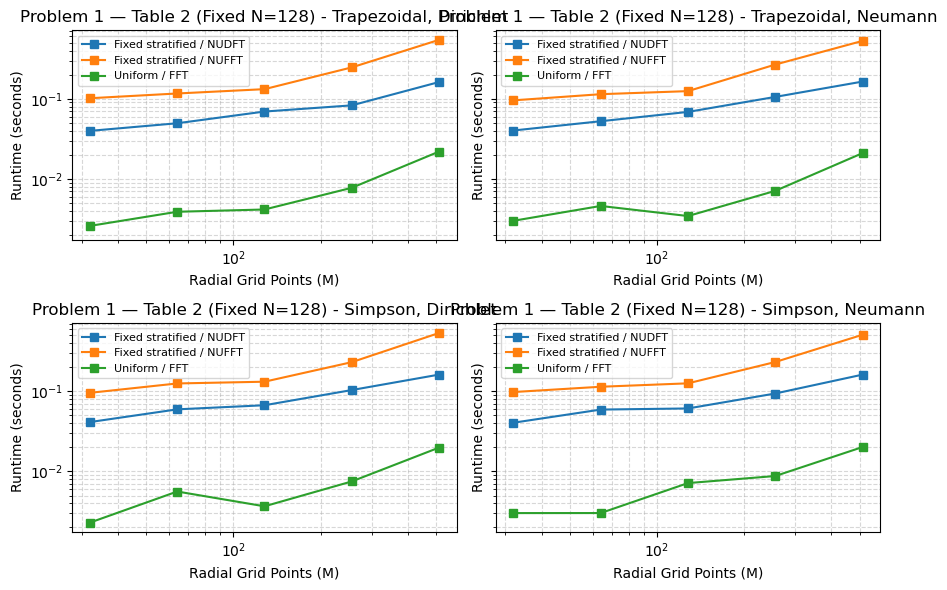


Slightly Nonuniform Angular-Grid Comparison: Runtime vs. N
Varying angular resolution N; fixed radial resolution M=128

Runtime Comparison (Fixed M=128) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed jittered / NUDFT,Fixed stratified_rand / NUDFT,Fixed jittered / NUFFT,Fixed stratified_rand / NUFFT
N,,,,,,,
32,0.0037,0.0098,0.0392,0.0097,0.0071,0.0307,0.0315
64,0.0035,0.0112,0.0378,0.0145,0.0185,0.0360,0.0420
128,0.0040,0.0621,0.0970,0.0689,0.0672,0.0963,0.1191
256,0.0079,0.1846,0.0935,0.2142,0.2060,0.1534,0.3637
512,0.0228,0.6295,0.1109,0.7640,0.7717,0.4069,1.0110


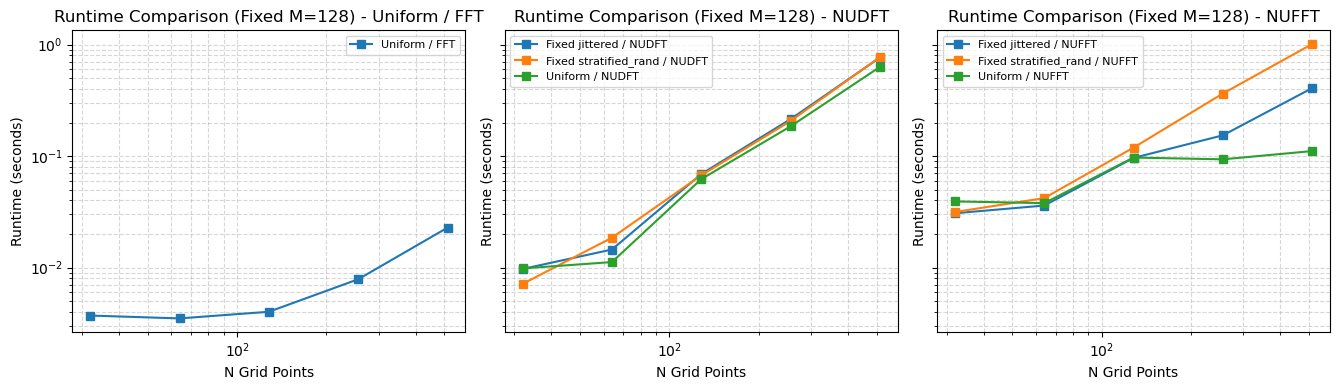


Slightly Nonuniform Angular-Grid Comparison: Runtime vs. M
Varying radial resolution M; fixed angular resolution N=128

Runtime Comparison (Fixed N=128) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed jittered / NUDFT,Fixed stratified_rand / NUDFT,Fixed jittered / NUFFT,Fixed stratified_rand / NUFFT
M,,,,,,,
32,0.0046,0.0506,0.0436,0.0492,0.0487,0.0712,0.0884
64,0.0058,0.0485,0.0580,0.0528,0.0517,0.0747,0.1064
128,0.0048,0.0588,0.0891,0.0662,0.0683,0.1031,0.1206
256,0.0077,0.0716,0.1726,0.0952,0.0962,0.1698,0.2267
512,0.0227,0.1139,0.3003,0.1842,0.1814,0.3823,0.5778


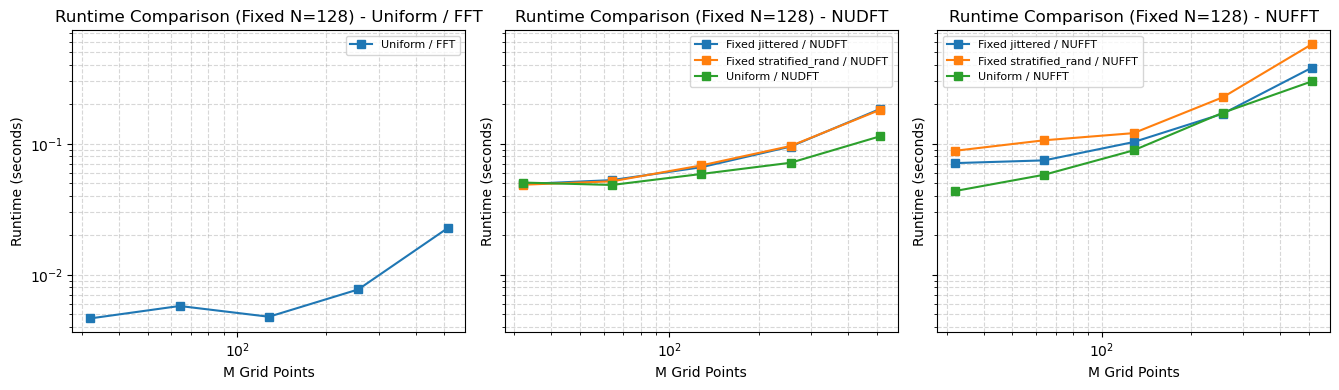

In [6]:

print("\nProblem 1 — Table 1: Runtime over angular and radial resolutions")
print("Methods: uniform FFT and fixed stratified-random NUDFT/NUFFT")
render_runtime(
    df_p1_t1,
    index_col="N",
    columns_col=["label", "M"],
    title_prefix="Problem 1 — Table 1"
)
plot_runtime_table1(df_p1_t1, title_prefix="Problem 1 — Table 1")

print(f"\nProblem 1 — Table 2: Runtime by quadrature rule and boundary condition (N={N_fixed_p1})")
print("Methods: uniform FFT and fixed stratified-random NUDFT/NUFFT")
render_table2_runtime(
    df_p1_t2,
    title_prefix=f"Problem 1 — Table 2 (Fixed N={N_fixed_p1})"
)
plot_runtime_table2(
    df_p1_t2,
    title_prefix=f"Problem 1 — Table 2 (Fixed N={N_fixed_p1})"
)

print("\nSlightly Nonuniform Angular-Grid Comparison: Runtime vs. N")
print(f"Varying angular resolution N; fixed radial resolution M={M_fixed_c}")
render_runtime(
    df_cN,
    index_col="N",
    columns_col="label",
    title_prefix=f"Runtime Comparison (Fixed M={M_fixed_c})"
)
plot_runtime_comparison(
    df_cN,
    index_col="N",
    title_prefix=f"Runtime Comparison (Fixed M={M_fixed_c})"
)

print("\nSlightly Nonuniform Angular-Grid Comparison: Runtime vs. M")
print(f"Varying radial resolution M; fixed angular resolution N={N_fixed_c}")
render_runtime(
    df_cM,
    index_col="M",
    columns_col="label",
    title_prefix=f"Runtime Comparison (Fixed N={N_fixed_c})"
)
plot_runtime_comparison(
    df_cM,
    index_col="M",
    title_prefix=f"Runtime Comparison (Fixed N={N_fixed_c})"
)